# 05 - Statistics & Exploring STATS19

Here I check out the STATS19 merged data and find out and visualise interesting trends about it

In [2]:
import pandas as pd
df = pd.read_csv('../data/STATS19/dft_STATS19_1979_23_SY.csv', low_memory=False)
print(df.shape)

# Show missing value counts
print(df.isnull().sum())
duplicates = df[df.duplicated(subset="accident_index", keep=False)]
print(f"Number of duplicate accident_index values: {len(duplicates)}")
print(df.size)
# Get the duplicate accident_reference values (the IDs that appear more than once)
duplicate_ids = df["accident_index"][df["accident_index"].duplicated()].unique()

# Filter rows with these duplicate accident_index values
# dupe_rows = df[df["accident_index"].isin(duplicate_ids)]

# Show the first 10 duplicates
# print(dupe_rows.sort_values("accident_index").head(10))

(243191, 85)
accident_index                  0
accident_year                   0
accident_reference              0
vehicle_reference               0
casualty_reference              0
                            ...  
dir_from_e                 237569
dir_from_n                 237569
dir_to_e                   237598
dir_to_n                   237598
driver_distance_banding         0
Length: 85, dtype: int64
Number of duplicate accident_index values: 103729
20671235


In [3]:
final_data = df
print(f"Final rows: {len(final_data)}")
print(f"Unique accidents: {final_data['accident_index'].nunique()}")
print(f"Unique casualties: {final_data['casualty_reference'].nunique()}")
print(f"Unique vehicles: {final_data['vehicle_reference'].nunique()}")


Final rows: 243191
Unique accidents: 180391
Unique casualties: 76
Unique vehicles: 20


In [16]:
import pandas as pd

# Step 1: Count how many rows (casualties) per accident
row_counts = df.groupby('accident_index').size()

# Step 2: Count how many accidents have N rows
accident_size_distribution = row_counts.value_counts().sort_index()

# # Convert to DataFrame for easier viewing
# asd = accident_size_distribution.reset_index()
# asd.columns = ['number_of_rows_per_accident', 'number_of_accidents']

# # Calculate total rows (accidents * rows)
# asd['total_rows'] = asd['number_of_rows_per_accident'] * asd['number_of_accidents']

# # Display DataFrame
# display(asd)

# # Optional: Display total row summary
# total_calculated_rows = asd['total_rows'].sum()
# print(f"\nTotal rows calculated: {total_calculated_rows:,}")
# print(f"Original DataFrame rows: {len(df):,}")


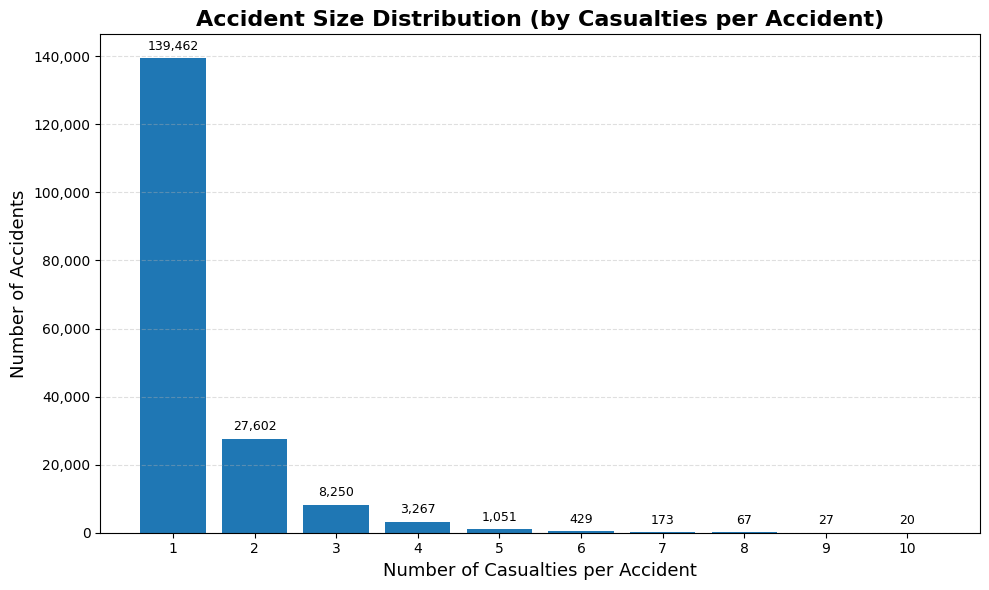

In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
# accident_size_distribution = asd['count']
# Trim to a reasonable max (e.g., accidents with up to 10 casualties)
filtered = accident_size_distribution[accident_size_distribution.index <= 10]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(filtered.index, filtered.values, color='#1f77b4')

# Title and labels
ax.set_title("Accident Size Distribution (by Casualties per Accident)", fontsize=16, weight='bold')
ax.set_xlabel("Number of Casualties per Accident", fontsize=13)
ax.set_ylabel("Number of Accidents", fontsize=13)

# Format y-axis numbers with commas
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Add value labels only if count is meaningful
for bar in bars:
    height = bar.get_height()
    if height > 10:  # skip labeling tiny bars
        ax.annotate(f'{int(height):,}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=9)

# Adjust ticks and layout
plt.xticks(filtered.index)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.savefig("accident_size_distribution_cleaned.png", dpi=300)
plt.show()


# Routes

In [1]:
# autoreload setup
%load_ext autoreload
%autoreload 2

# imports
import sys
from pathlib import Path
sys.path.append(str(Path('..') / 'util'))
import dataset_stats as dfs
import pandas as pd

df = pd.read_csv('../data/stats19_routes_combined.csv', low_memory=False)

Collision Overlap Summary:
Total rows (with duplicates): 536471
Total unique collisions: 17747
Collisions shared across multiple routes: 14727
Collisions unique to one route: 3020
Max routes a single collision appears in: 61
Average routes per collision: 7.13
% of collisions shared across routes: 82.98%

Most shared collisions:
      accident_index  num_routes
2980   199814CC00668          61
10016  200314CC00668          61
11599  200414CC00668          61
7126   200114CC00668          61
8619   200214CC00668          61
16876  2019140845361          48
1163   199614GG00697          47
10637  200314GG00697          47
7748   200114GG00697          47
3472   199814GG00697          47


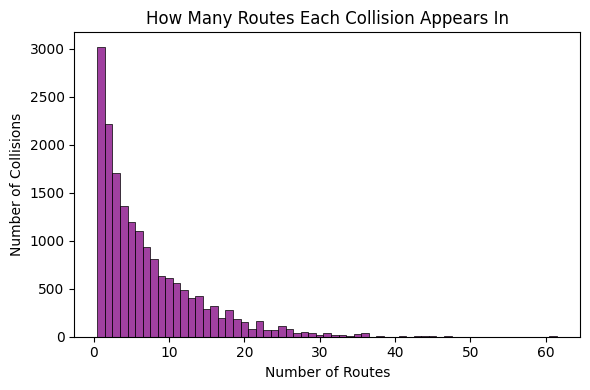

,accident_index,num_routes
0,197914A102209,6
1,197914B100510,6
2,197914B101511,1
3,197914B101606,9
4,197914B101710,4
...,...,...
17742,2023141391208,18
17743,2023141391522,6
17744,2023141392071,4
17745,2023141392129,12


In [2]:
dfs.collision_overlap_summary(df)

📊 Averages:
• Avg collisions per route: 101.86
• Avg collisions per school: 1136.59

🏆 Top 20 Routes by Collision Count:
                                        route_id  collision_count
0                 ecclesfield_secondary_school_2             2901
1                 ecclesfield_secondary_school_3             2790
2   handsworth_grange_community_sports_college_6             2784
3                           brinsworth_academy_4             2398
4               halfway_nursery_infant_school_13             2065
5               halfway_nursery_infant_school_14             2065
6                      meersbrook_bank_primary_0             1685
7                          pennine_view_school_4             1663
8                             carfield_primary_4             1628
9                           thrybergh_academy_13             1529
10                          de_warenne_academy_3             1525
11                          thrybergh_academy_14             1518
12                   

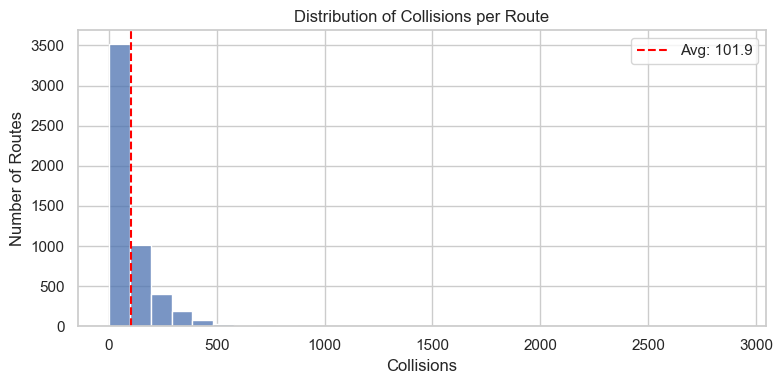

f:\Uni Files\Semester 2\STATS19_route_risk_analysis\notebooks\..\util\dataset_stats.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_schools.values, y=top_schools.index, palette="Blues_d")


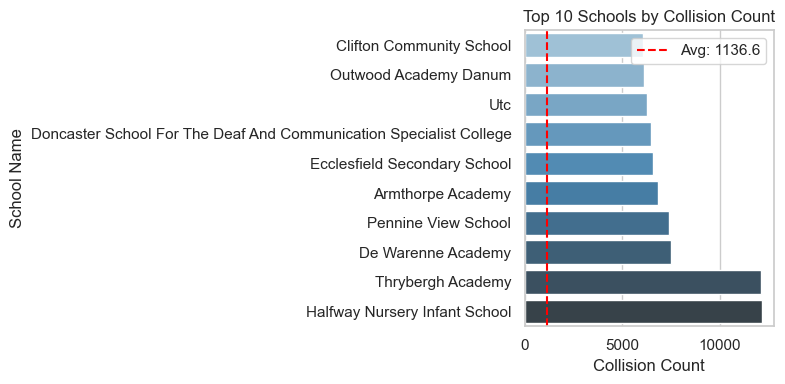

f:\Uni Files\Semester 2\STATS19_route_risk_analysis\notebooks\..\util\dataset_stats.py:119: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_routes.values, y=top_routes.index, palette="Greens_d")


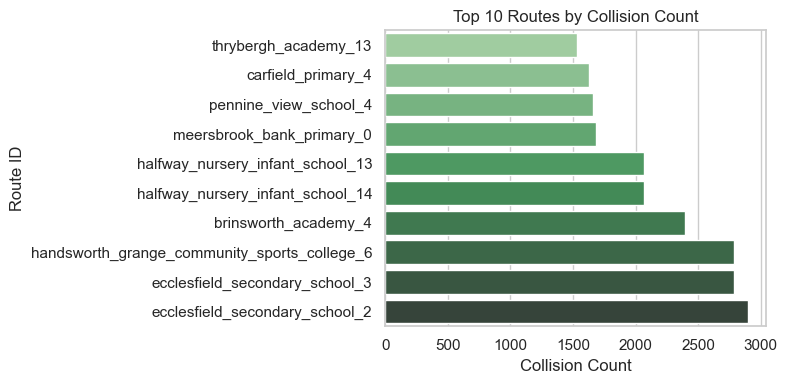

In [3]:
dfs.visualise_collision_summaries(df)

📊 Averages:
• Avg collisions per route: 101.86
• Avg collisions per km: 26.75
• Avg collisions per school: 1136.59

🏆 Top Routes by Collision Count:
                                    route_id                                     school  collisions
              ecclesfield_secondary_school_2               Ecclesfield Secondary School        2901
              ecclesfield_secondary_school_3               Ecclesfield Secondary School        2790
handsworth_grange_community_sports_college_6 Handsworth Grange Community Sports College        2784
                        brinsworth_academy_4                         Brinsworth Academy        2398
            halfway_nursery_infant_school_13              Halfway Nursery Infant School        2065
            halfway_nursery_infant_school_14              Halfway Nursery Infant School        2065
                   meersbrook_bank_primary_0                    Meersbrook Bank Primary        1685
                       pennine_view_school_4       

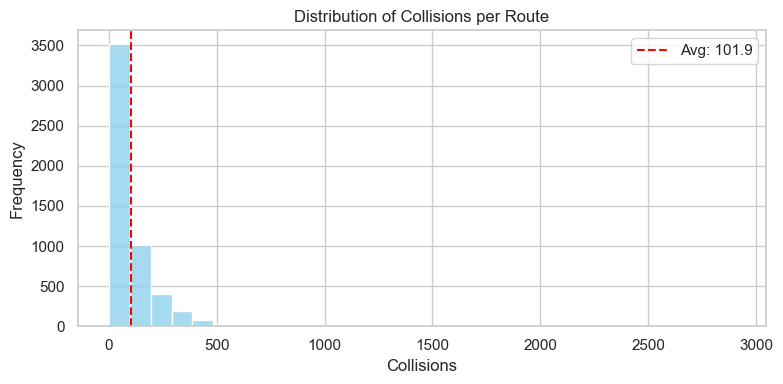

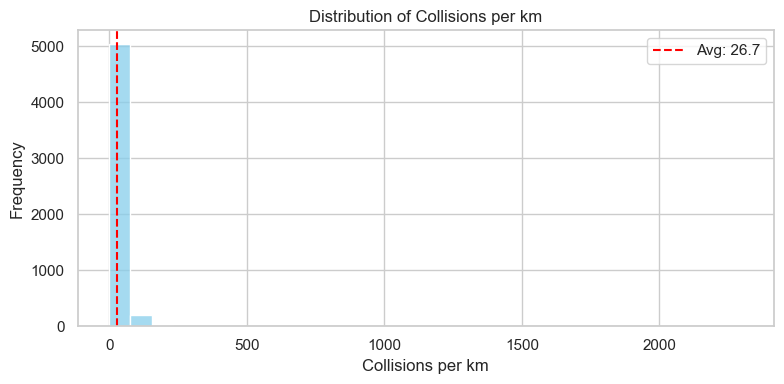

f:\Uni Files\Semester 2\STATS19_route_risk_analysis\notebooks\..\util\dataset_stats.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  print("\n🏆 Top 20 Routes by Collision Count:")


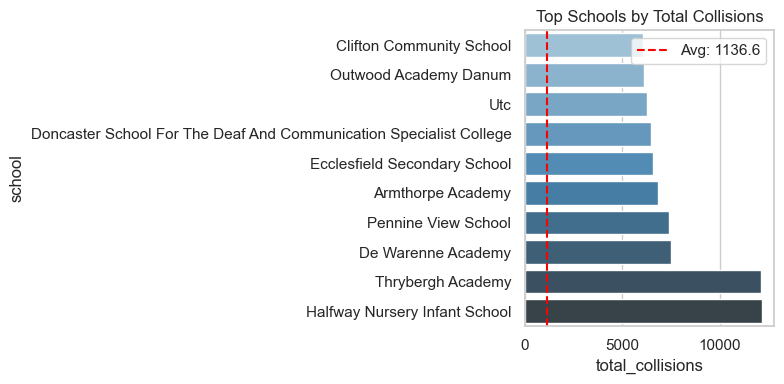

f:\Uni Files\Semester 2\STATS19_route_risk_analysis\notebooks\..\util\dataset_stats.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  print("\n🏆 Top 20 Routes by Collision Count:")


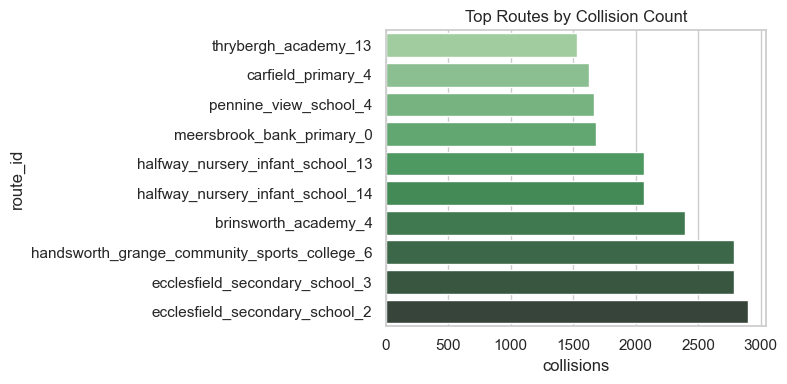

f:\Uni Files\Semester 2\STATS19_route_risk_analysis\notebooks\..\util\dataset_stats.py:84: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  print("\n🏆 Top 20 Routes by Collision Count:")


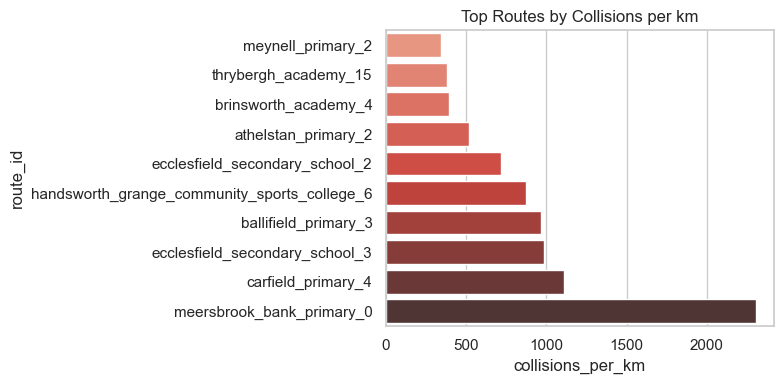

In [4]:
dfs.summarise_and_visualise_route_school_stats(df)

In [ ]:
# Compare casualty severity in whole routes dataset
merged["casualty_severity"].value_counts(normalize=True) * 100
import seaborn as sns
import matplotlib.pyplot as plt

# Count severity categories
severity_counts = merged["casualty_severity"].value_counts().reindex(["Slight", "Serious", "Fatal"]).fillna(0)

# Plot
plt.figure(figsize=(6, 4))
sns.barplot(x=severity_counts.index, y=severity_counts.values, palette=["#88cc88", "#ffaa44", "#dd4444"])
plt.title("Casualty Severity on School Routes", fontsize=14)
plt.ylabel("Number of Casualties")
plt.xlabel("Severity Level")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Most at risk routes/schools
merged.groupby("route_id")["casualty_severity"].value_counts(normalize=True).unstack().fillna(0)
